# Exercise 4

## Imports

In [191]:
import copy
import math
from enum import Enum
from pathlib import Path
from typing import Dict, Optional

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series

## Constants

In [192]:
current_dir = Path.cwd()

# Music file
rock_audiofile_path = current_dir.joinpath("data", "rock.mp3")


class FeatureType(Enum):
    SPECTRAL_CENTROID = "spectral_centroid"
    ZERO_CROSSING_RATE = "zero_crossing_rate"
    ROOT_MEAN_SQUARED_ENERGY = "root_mean_squared_energy"


frame_lengths = [512, 760]

## Exercise 1

Load the file rock.mp3 from the week 2 exercises in Python and extract the following features with
librosa, once with a frame length of 512 and once with 760:
- Spectral centroid
- Zero-crossing rate
- Root mean squared energy (RMS)

See https://librosa.org/doc/latest/feature.html for documentation on how to extract the features.

In [193]:
def get_column_name(feature_type: FeatureType, frame_length: int) -> str:
    return f"{feature_type.value}-{frame_length}"


def extract_feature(feature_type: FeatureType, y: np.ndarray, sr: int, frame_length: int, hop_length: int) -> pd.Series:
    if feature_type is FeatureType.SPECTRAL_CENTROID:
        features = librosa.feature.spectral_centroid(y=y,
                                                     sr=sr,
                                                     n_fft=frame_length,
                                                     hop_length=hop_length, )
    elif feature_type is FeatureType.ZERO_CROSSING_RATE:
        features = librosa.feature.zero_crossing_rate(y=y,
                                                      hop_length=frame_length,
                                                      frame_length=hop_length, )
    elif feature_type is FeatureType.ROOT_MEAN_SQUARED_ENERGY:
        features = librosa.feature.rms(y=y,
                                       frame_length=frame_length,
                                       hop_length=hop_length, )
    else:
        raise ValueError(f"Unknown feature type: {feature_type}")

    return pd.Series(features.flatten(), name=get_column_name(feature_type, frame_length))


# Load audio file
y, sr = librosa.load(rock_audiofile_path)
# y -> audio time series
# sr -> sampling rate
n_samples = len(y)
print(f"n samples = {n_samples}")

# Feature dataframe
features_df = DataFrame()
feature_window_length_dict = {}

for frame_length in frame_lengths:
    print(f"Extracting features with frame length: {frame_length}")

    hop_length = frame_length  # Assuming no overlap

    for feature_type in FeatureType:
        new_feature_series = extract_feature(feature_type, y, sr, frame_length, hop_length)
        print(new_feature_series.shape)

        features_df = pd.concat([features_df, new_feature_series], axis=1)
        feature_window_length_dict[new_feature_series.name] = frame_length

print(features_df)
print(feature_window_length_dict)

n samples = 5003136
Extracting features with frame length: 512
(9772,)
(9772,)
(9772,)
Extracting features with frame length: 760
(6584,)
(6584,)
(6584,)
      spectral_centroid-512  zero_crossing_rate-512  \
0                  0.000000                0.000000   
1                  0.000000                0.000000   
2               6568.019614                0.000000   
3               5023.175337                0.000000   
4               4711.511930                0.210938   
...                     ...                     ...   
9767               0.000000                0.000000   
9768               0.000000                0.000000   
9769               0.000000                0.000000   
9770               0.000000                0.000000   
9771               0.000000                0.000000   

      root_mean_squared_energy-512  spectral_centroid-760  \
0                     0.000000e+00               0.000000   
1                     0.000000e+00            7406.149386   
2 

### Visualization

In [194]:
def feature_is_harmonized(feature_name: str) -> bool:
    return "_(" in feature_name


def plot_features_section(features_df: DataFrame, feature_window_length_dict: Dict[str, int], start_sample: int,
                          end_sample: int, columns=None, harmonized_overlay: bool = False):
    """
    Visualizes features over a specific sample range with window length indicators.

    :param features_df: DataFrame containing feature series
    :param feature_window_length_dict: Dictionary mapping column names to their frame length
    :param start_sample: Start sample for the visualization window
    :param end_sample: End sample for the visualization window
    :param columns: List of columns to plot (optional, defaults to all)
    """
    if columns is None:
        columns = features_df.columns

    # Collect all unique window lengths from the columns being plotted
    window_lengths = set()
    for col in columns:
        if col in feature_window_length_dict:
            window_lengths.add(feature_window_length_dict[col])
    window_lengths = sorted(window_lengths)

    # Assign colors to each unique window length
    colors = plt.cm.Set1(range(len(window_lengths)))
    window_color_map = {wl: colors[i] for i, wl in enumerate(window_lengths)}

    # Create subplots
    n_features = len(columns)
    fig, axes = plt.subplots(n_features, 1, figsize=(15, 3 * n_features))  #, sharex=True)

    if n_features == 1:
        axes = [axes]

    for ax, feature_name in zip(axes, columns):
        ticks = []
        # Get frame length
        frame_len = feature_window_length_dict.get(feature_name)
        if frame_len is None:
            continue

        # Select data
        series = features_df[feature_name]

        # Normalize globally (Min-Max scaling to [0, 1])
        series_norm = get_min_max_normalized_series(series)

        # Determine indices of frames that fall into the sample window
        start_idx = max(0, math.floor(start_sample / frame_len))
        end_idx = min(len(series_norm), math.ceil(end_sample / frame_len))

        # Slice data for the relevant frames
        subset_series = series_norm.iloc[start_idx:end_idx]

        # Plot bars representing the windows
        x = subset_series.index * frame_len
        height = subset_series.values
        ax.bar(x, height, width=frame_len, align='edge', color="grey", edgecolor='black', alpha=1)

        if harmonized_overlay and feature_is_harmonized(feature_name):
            og_feature_name = feature_name.split("_(")[0]
            og_frame_len = feature_window_length_dict.get(og_feature_name)

            # Select data
            og_series = features_df[og_feature_name]

            # Normalize globally (Min-Max scaling to [0, 1])
            og_series_norm = get_min_max_normalized_series(og_series)

            # Determine indices of frames that fall into the sample window
            start_idx = max(0, math.floor(start_sample / og_frame_len))
            end_idx = min(len(og_series_norm), math.ceil(end_sample / og_frame_len))

            # Slice data for the relevant frames
            og_subset_series = og_series_norm.iloc[start_idx:end_idx]

            # Plot bars representing the windows
            x = og_subset_series.index * og_frame_len
            height = og_subset_series.values
            ax.bar(x, height, width=og_frame_len, align='edge', color="blue", edgecolor='black', hatch='/', alpha=0.2)

        # Plot vertical lines for all window lengths
        for wl in window_lengths:
            # Calculate line positions for this window length
            first_line = math.ceil(start_sample / wl) * wl
            line_positions = range(first_line, end_sample + 1, wl)

            # Use solid line for the current feature's window length, dashed for others
            linestyle = '-' if wl == frame_len else '--'
            alpha = 1.0 if wl == frame_len else 0.6
            color = window_color_map[wl]

            for pos in line_positions:
                ax.axvline(x=pos, color=color, linestyle=linestyle, alpha=alpha, linewidth=2)
                if wl == frame_len:
                    ticks.append(pos)

        ax.set_ylabel(f"{feature_name}\n (min-max normalized)", rotation=90, ha='center', fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(ticks)
        ax.set_xlim(start_sample, end_sample)

        # Create legend
        legend_elements = []
        for wl in window_lengths:
            color = window_color_map[wl]
            linestyle = '-' if wl == frame_len else '--'
            legend_elements.append(plt.Line2D([0], [0], color=color, linestyle=linestyle,
                                              label=f'Window length: {wl} (samples)', linewidth=2))
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

    for ax in axes:
        ax.tick_params(labelbottom=True)

    # Set x-axis limits and label
    axes[-1].set_xlabel(f'Samples ({sr} samples = 1 second)')
    plt.suptitle(f"Normalized Features View (Samples {start_sample} - {end_sample})")
    plt.tight_layout()
    plt.show()


def get_min_max_normalized_series(series: Series) -> Series:
    s_min = series.min()
    s_max = series.max()
    if s_max > s_min:
        series_norm = (series - s_min) / (s_max - s_min)
    else:
        series_norm = series - s_min
    return series_norm

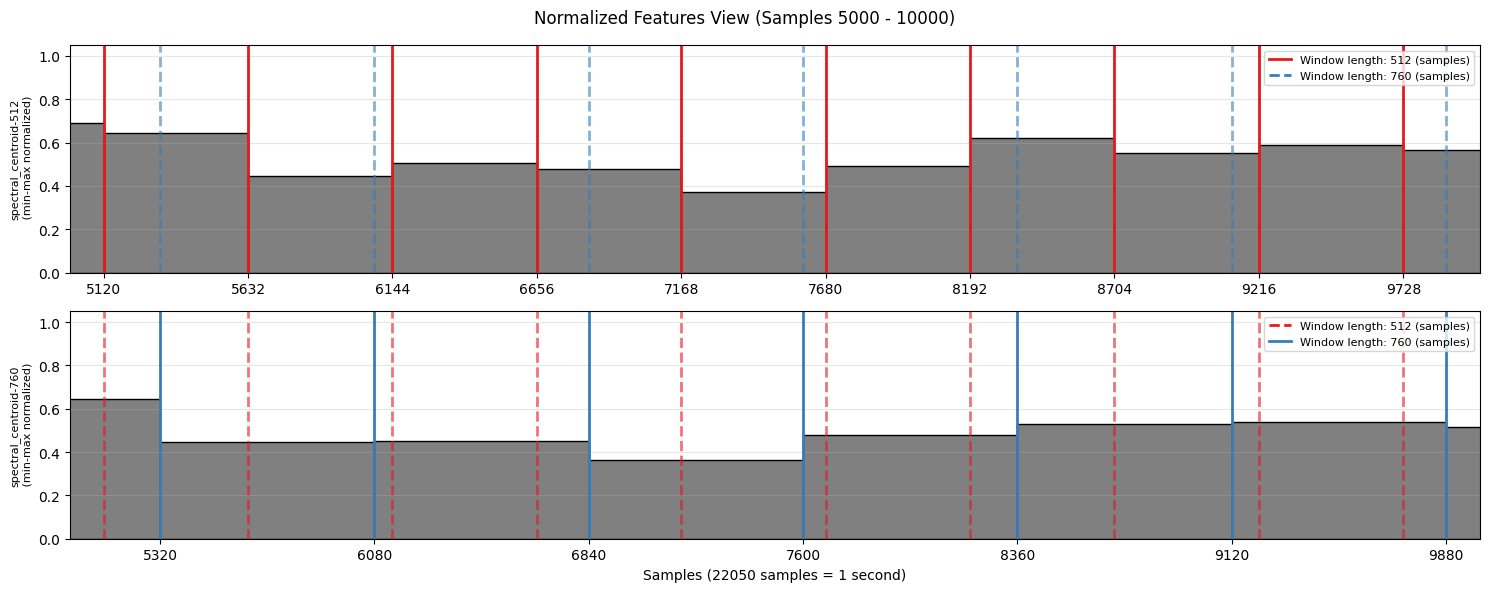

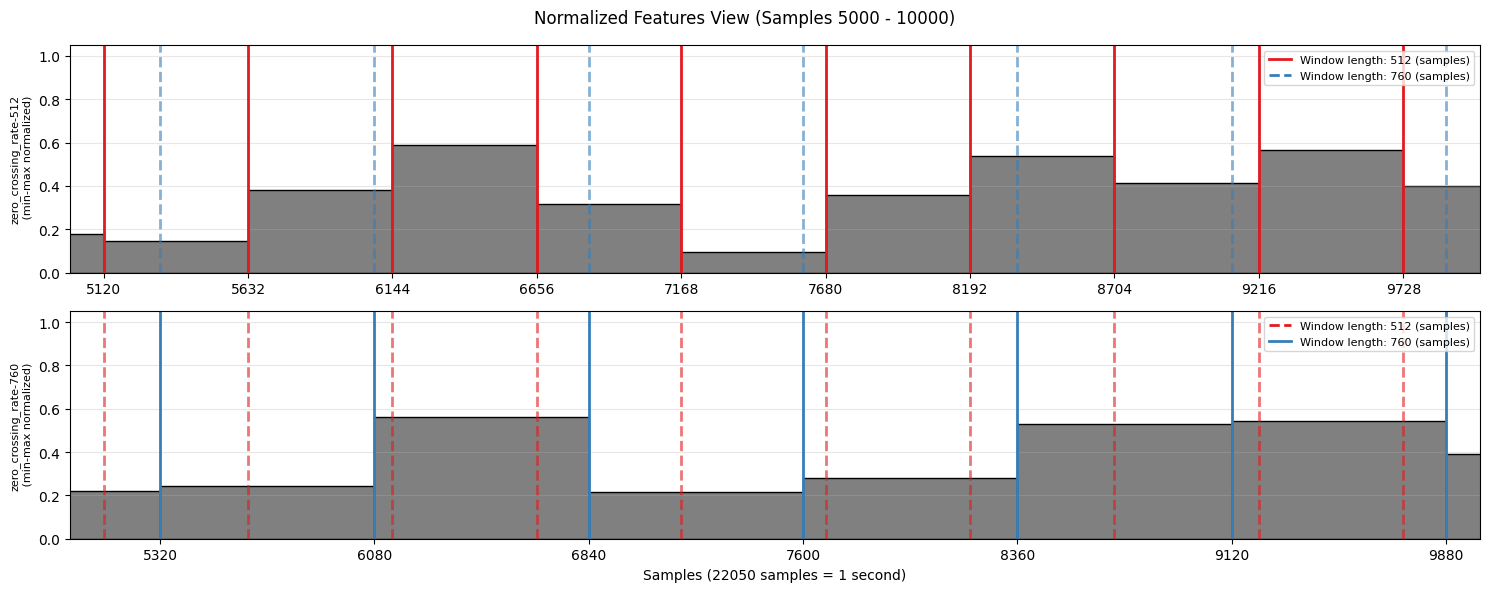

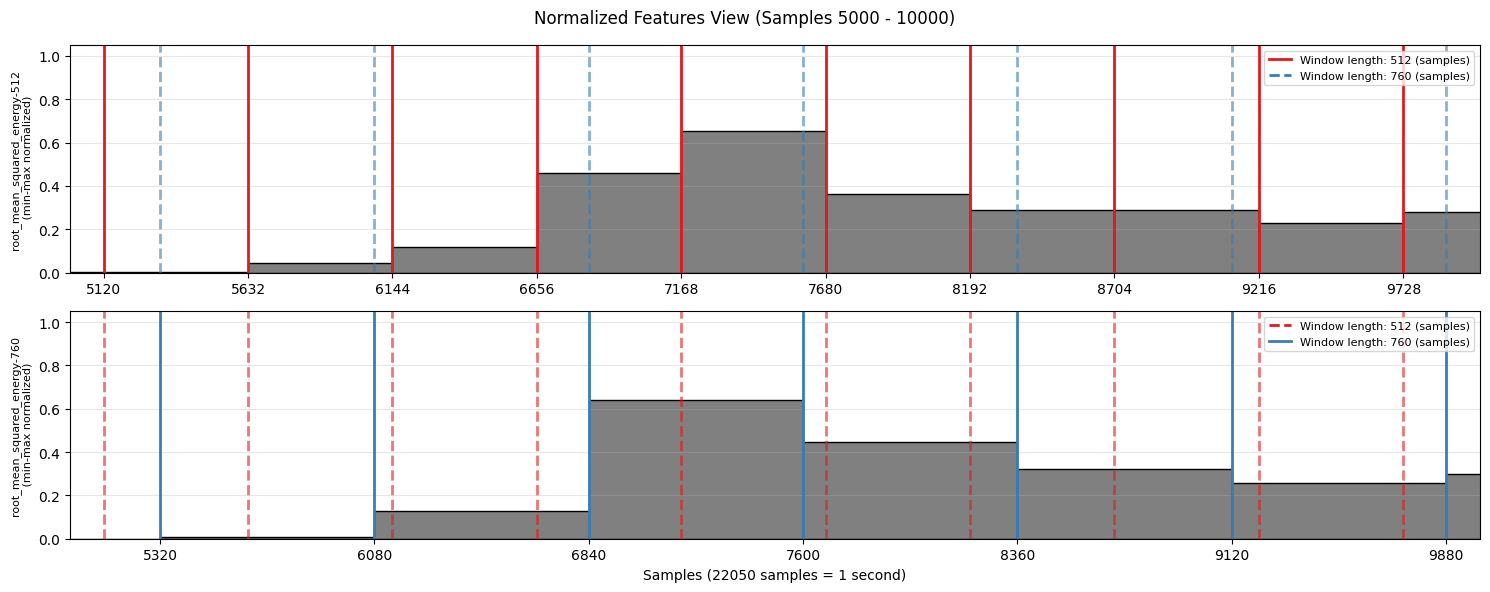

In [195]:
def visualize_all_feature_plots(df: DataFrame, feature_window_length_dict: Dict[str, int], start_sample: int = 5000,
                                end_sample: int = 10000):
    for feature in FeatureType:
        col1 = get_column_name(feature, frame_lengths[0])
        col2 = get_column_name(feature, frame_lengths[1])
        plot_features_section(df, feature_window_length_dict, start_sample=start_sample, end_sample=end_sample,
                              columns=[col1, col2])


visualize_all_feature_plots(features_df, feature_window_length_dict)

## Exercise 2

Given the features from Exercise 1, calculate a harmonised feature matrix for all six feature vectors.
The features should be harmonised to the frame length of fmin = 512.
First, use the harmonisation method shown on slide 18 and 19 of the lecture “Feature Processing and
Selection”.
Then, do the same by using a weighted average method in which features of adjacent frames are
weighted by their overlap ratio with the new frame.

In [196]:
def get_min_feature_length(feature_window_lengths: Dict[str, int]) -> int:
    return min(feature_window_lengths.values())


class HarmonizationMethod(Enum):
    SELECTION = "selection"
    AVERAGE = "average"


def get_hm_column_name(series_name: str, min_feature_length: int, harmonization_method: HarmonizationMethod) -> str:
    return f"{series_name}_({min_feature_length}-{harmonization_method.value})"


def harmonization_matrix(df: DataFrame, feature_window_lengths_dict: Dict[str, int], total_samples: int,
                         harmonization_method: HarmonizationMethod = HarmonizationMethod.SELECTION,
                         min_feature_length: Optional[int] = None) -> DataFrame:
    """

    :param df: multiple series corresponding to different features.
        Can have trailing Nands.
        It is also assumed that each feature processes all samples.
    :param feature_window_lengths_dict:
    :param min_feature_length:
    :return:
    """
    if min_feature_length is None:
        min_feature_length = get_min_feature_length(feature_window_lengths_dict)

    num_windows = math.ceil(total_samples / min_feature_length)

    new_feature_window_lengths = copy.deepcopy(feature_window_lengths_dict)

    hm_df = pd.DataFrame()
    for series_name in df:
        window_length = feature_window_lengths_dict[series_name]
        if window_length > min_feature_length:
            hf = []
            for w in range(num_windows):
                a = min_feature_length * w  # Previous border
                c = a + min_feature_length  # Next border

                prev_opt_idx = a // window_length  # First idx
                next_opt_idx = prev_opt_idx + 1  # Second idx
                assert prev_opt_idx >= 0, f"prev_opt_idx={prev_opt_idx} for window {w}"

                b = window_length * next_opt_idx
                if b < a or b > c:
                    new_val = df[series_name][next_opt_idx] if b < a else df[series_name][prev_opt_idx]
                else:
                    w_first_len = b - a
                    w_second_len = c - b
                    assert w_first_len >= 0, f"negative w_first_len={w_first_len} for window {w}"
                    assert w_second_len >= 0, f"negative w_second_len={w_second_len} for window {w}"
                    assert w_first_len + w_second_len == min_feature_length

                    if harmonization_method is HarmonizationMethod.SELECTION:
                        new_val = df[series_name][prev_opt_idx] if w_first_len > w_second_len else df[series_name][
                            next_opt_idx]
                    elif harmonization_method is HarmonizationMethod.AVERAGE:
                        new_val = (df[series_name][prev_opt_idx] * w_first_len + df[series_name][
                            next_opt_idx] * w_second_len) / min_feature_length

                    assert (round(df[series_name][prev_opt_idx], 8) <= round(new_val, 8) <= round(
                        df[series_name][next_opt_idx], 8)) or (
                                   round(df[series_name][prev_opt_idx], 8) >= round(new_val, 8) >= round(
                               df[series_name][next_opt_idx],
                               8)), f"{df[series_name][prev_opt_idx]} - {new_val} - {df[series_name][next_opt_idx]} for window {w}"

                hf.append(new_val)

            new_series_name = get_hm_column_name(series_name, min_feature_length, harmonization_method)

            hm_df[new_series_name] = pd.Series(hf)
        else:
            new_series_name = series_name

        hm_df[series_name] = df[series_name].copy()  # Always copy original series to new column.
        new_feature_window_lengths[new_series_name] = min_feature_length  # OG already in dict, so no need to update.

    return hm_df, min_feature_length, new_feature_window_lengths

## 2.1 - Harmonisation of feature matrix 1: SELECTION

In [197]:
hm1_df, min_feature_length, hm1_feature_lengths_dict = harmonization_matrix(features_df, feature_window_length_dict,
                                                                            n_samples,
                                                                            HarmonizationMethod.SELECTION)
print(f"min_feature_length: {min_feature_length}")
print(hm1_df)

min_feature_length: 512
      spectral_centroid-512  zero_crossing_rate-512  \
0                  0.000000                0.000000   
1                  0.000000                0.000000   
2               6568.019614                0.000000   
3               5023.175337                0.000000   
4               4711.511930                0.210938   
...                     ...                     ...   
9767               0.000000                0.000000   
9768               0.000000                0.000000   
9769               0.000000                0.000000   
9770               0.000000                0.000000   
9771               0.000000                0.000000   

      root_mean_squared_energy-512  spectral_centroid-760_(512-selection)  \
0                     0.000000e+00                               0.000000   
1                     0.000000e+00                            7406.149386   
2                     1.674096e-22                            7406.149386   
3      

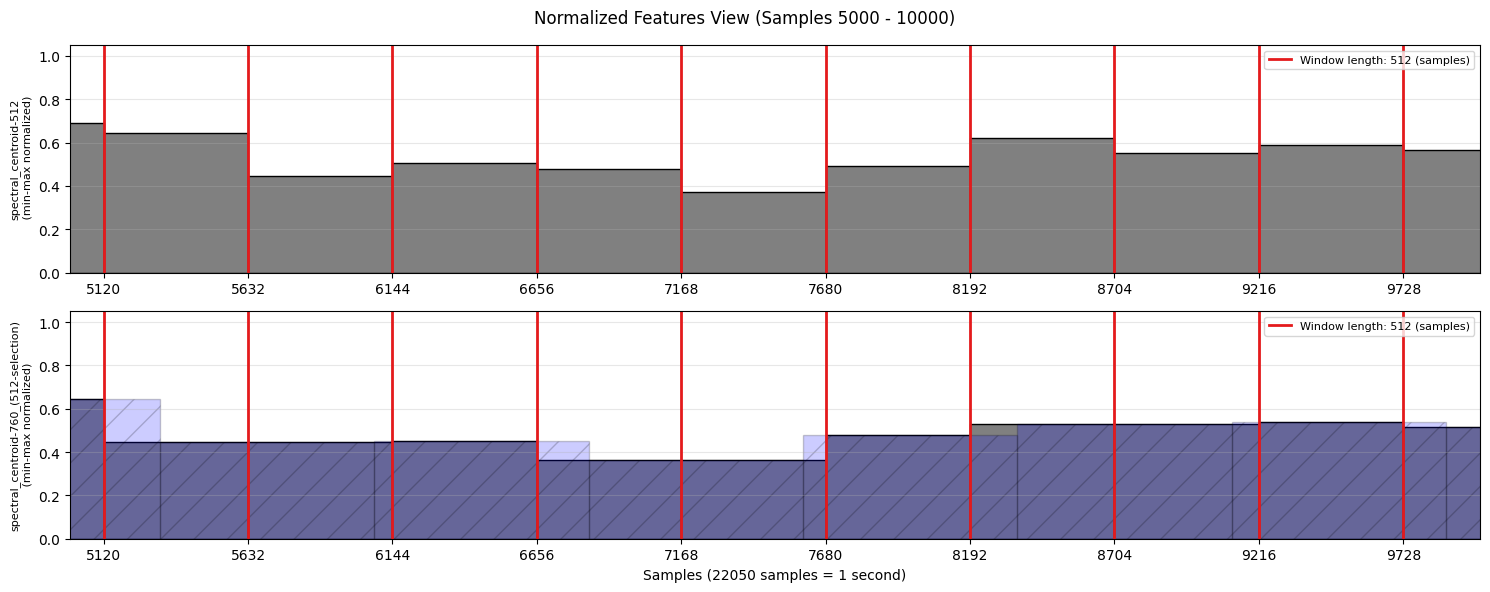

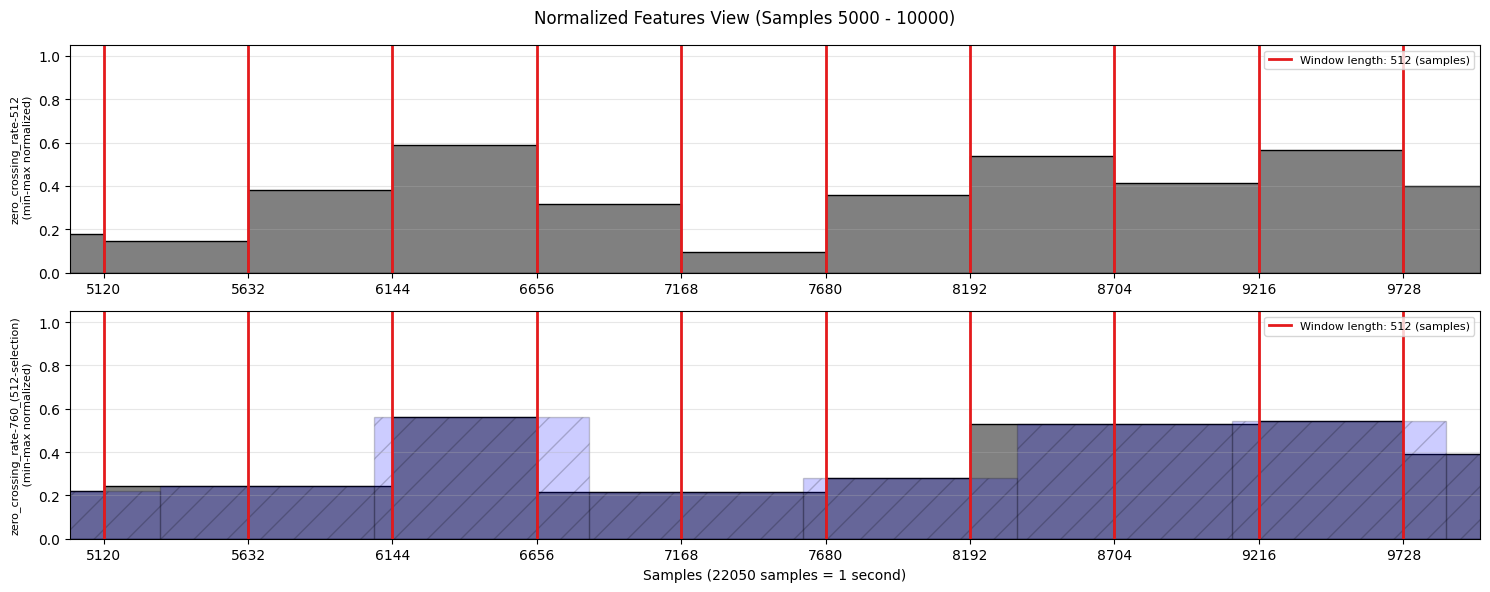

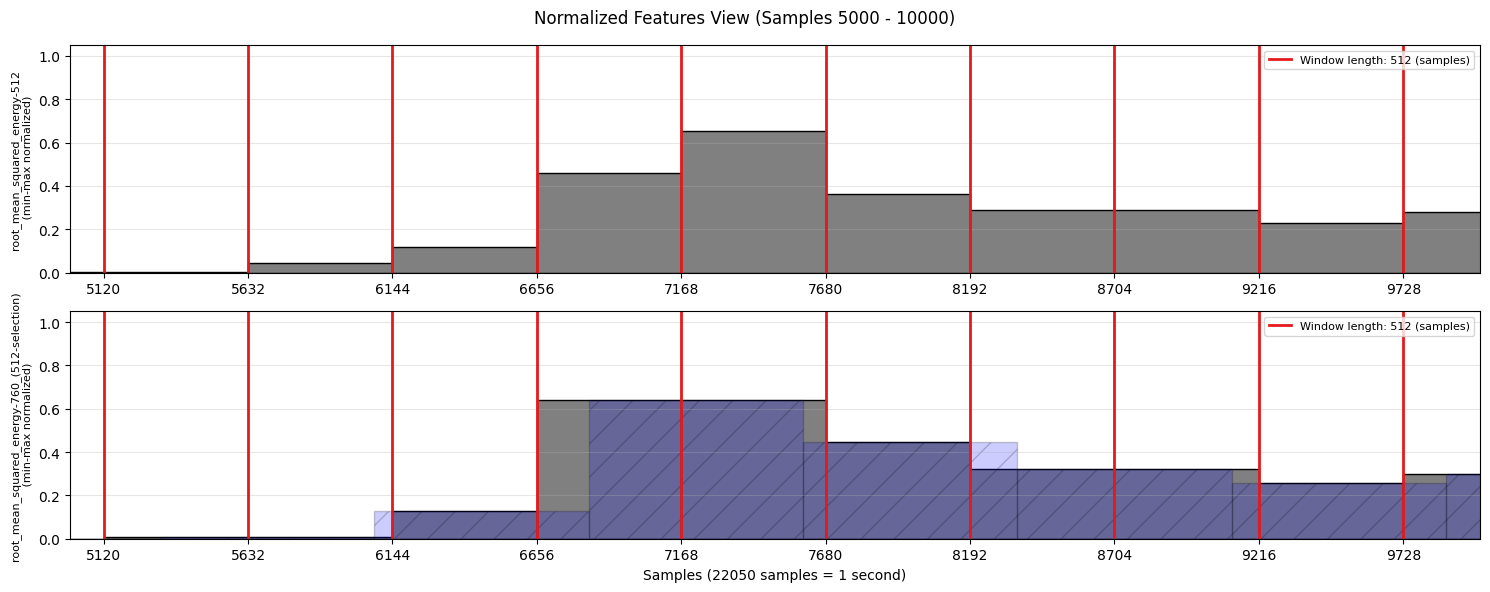

In [198]:
def visualize_all_hm_feature_plots(df: DataFrame, feature_window_length_dict: Dict[str, int],
                                   harmonization_method: HarmonizationMethod, start_sample: int = 5000,
                                   end_sample: int = 10000, harmonized_overlay: bool = False):
    for feature in FeatureType:
        col1 = get_column_name(feature, frame_lengths[0])
        col2 = get_hm_column_name(get_column_name(feature, frame_lengths[1]), frame_lengths[0], harmonization_method)
        plot_features_section(df, feature_window_length_dict, start_sample=start_sample, end_sample=end_sample,
                              columns=[col1, col2], harmonized_overlay=harmonized_overlay)


visualize_all_hm_feature_plots(hm1_df, hm1_feature_lengths_dict, HarmonizationMethod.SELECTION, harmonized_overlay=True)

## 2.2 - Harmonisation of feature matrix 2: AVERAGE

In [199]:
hm2_df, min_feature_length, hm2_feature_lengths_dict = harmonization_matrix(features_df, feature_window_length_dict,
                                                                            n_samples,
                                                                            HarmonizationMethod.AVERAGE)
print(f"min_feature_length: {min_feature_length}")
print(hm2_df)

min_feature_length: 512
      spectral_centroid-512  zero_crossing_rate-512  \
0                  0.000000                0.000000   
1                  0.000000                0.000000   
2               6568.019614                0.000000   
3               5023.175337                0.000000   
4               4711.511930                0.210938   
...                     ...                     ...   
9767               0.000000                0.000000   
9768               0.000000                0.000000   
9769               0.000000                0.000000   
9770               0.000000                0.000000   
9771               0.000000                0.000000   

      root_mean_squared_energy-512  spectral_centroid-760_(512-average)  \
0                     0.000000e+00                             0.000000   
1                     0.000000e+00                          3818.795777   
2                     1.674096e-22                          7332.203250   
3              

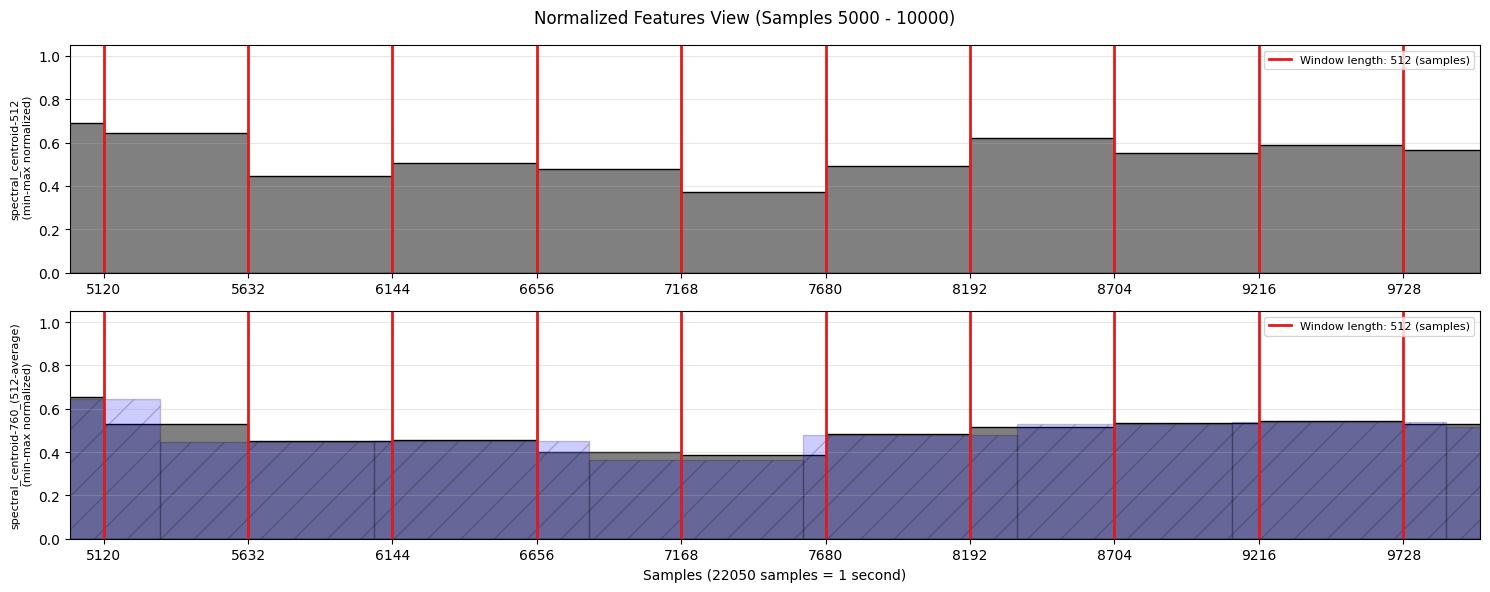

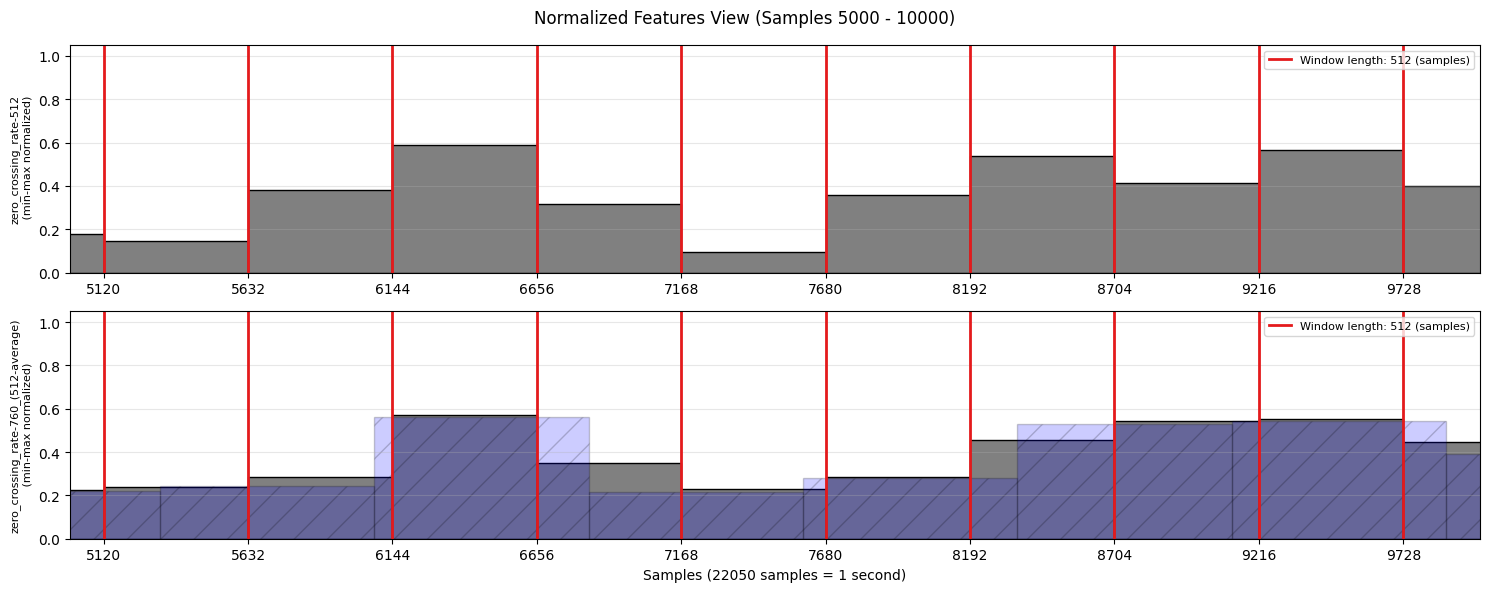

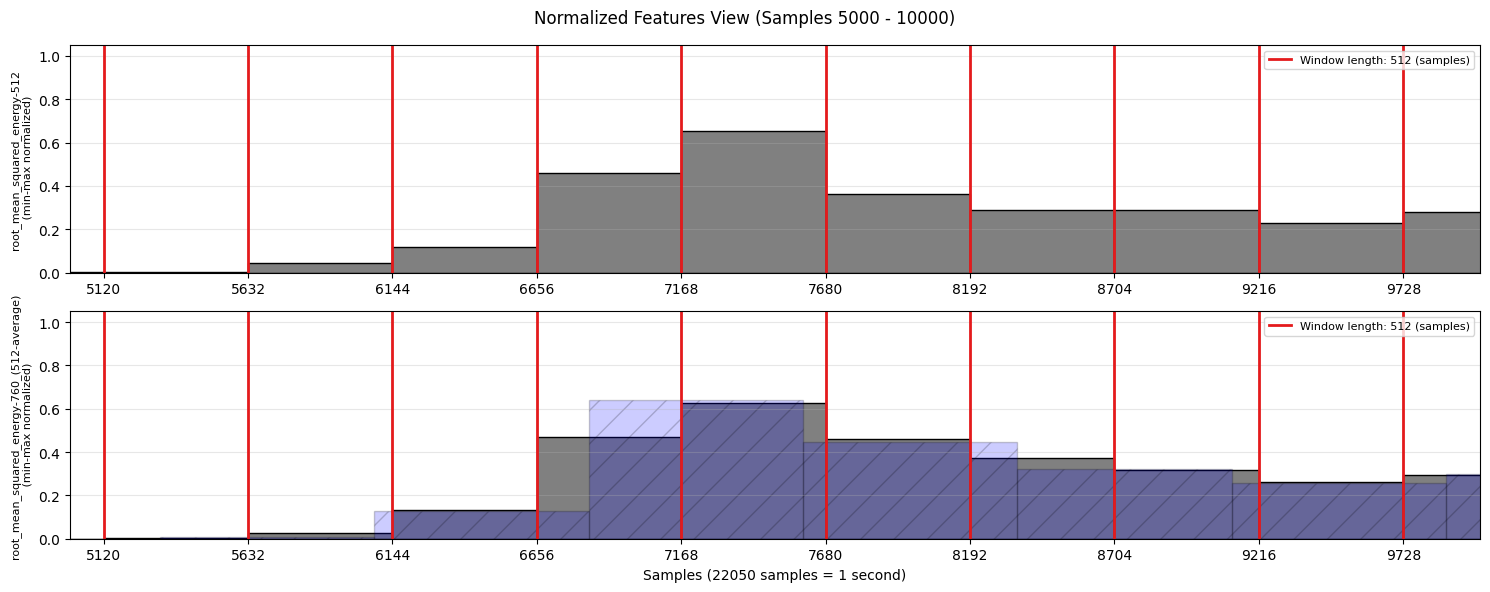

In [200]:
visualize_all_hm_feature_plots(hm2_df, hm2_feature_lengths_dict, HarmonizationMethod.AVERAGE, harmonized_overlay=True)

## Exercise 3

For each of three feature types, calculate the correlation between the features with frame length 512
from Exercise 1 and the harmonised features with original frame length 760.
Which harmonisation method achieves higher correlation with the extracted features?

Feature: spectral_centroid
Original features correlation: 0.7552137520271202
Harmonisation method 1 features correlation: 0.7898826095510326
Feature: zero_crossing_rate
Original features correlation: 0.8342267869415052
Harmonisation method 1 features correlation: 0.8664418824185262
Feature: root_mean_squared_energy
Original features correlation: 0.8511230170974846
Harmonisation method 1 features correlation: 0.8924410664319354


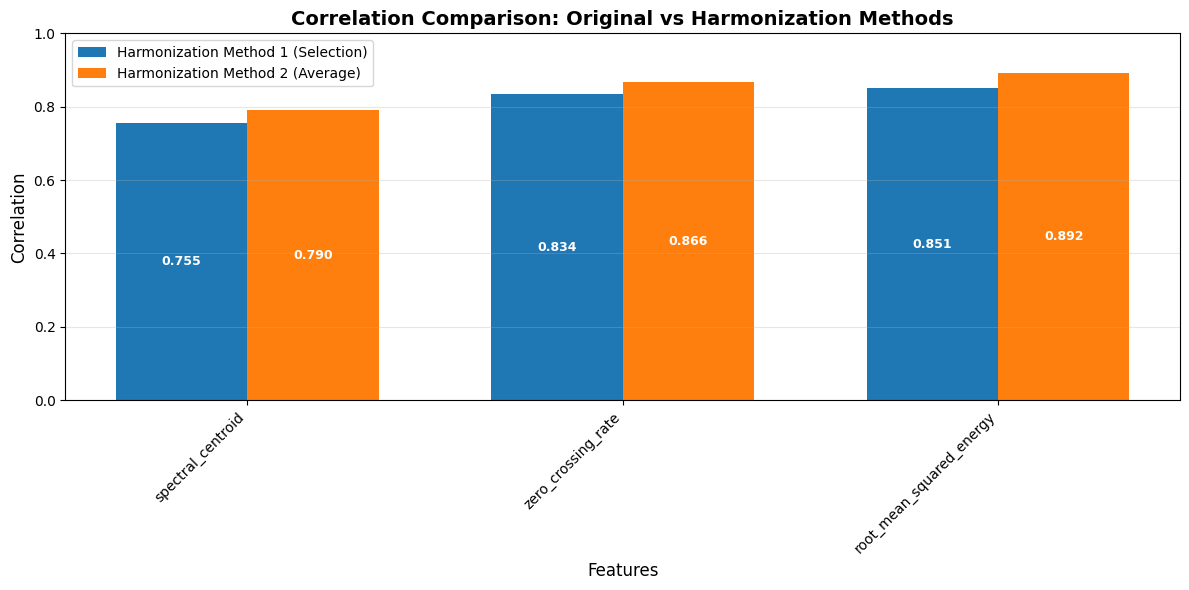

Difference between Harmonization Method 1 and Harmonization Method 2: [-0.03466886 -0.0322151  -0.04131805]
Average difference: -0.036 or -3.61%


In [201]:
features = []
h1_cor = []
h2_cor = []
for feature in FeatureType:
    og_feature_name = get_column_name(feature, frame_lengths[0])
    aux = get_column_name(feature, frame_lengths[1])
    hm1_feature_name = get_hm_column_name(aux, frame_lengths[0], HarmonizationMethod.SELECTION)
    hm2_feature_name = get_hm_column_name(aux, frame_lengths[0], HarmonizationMethod.AVERAGE)

    og_features = features_df[og_feature_name]
    hm1_features = hm1_df[hm1_feature_name]
    hm2_features = hm2_df[hm2_feature_name]

    og_features_corr = og_features.corr(hm1_features)
    hm1_features_corr = og_features.corr(hm2_features)

    print(f"Feature: {feature.value}")
    print(f"Original features correlation: {og_features_corr}")
    print(f"Harmonisation method 1 features correlation: {hm1_features_corr}")

    features.append(feature.value)
    h1_cor.append(og_features_corr)
    h2_cor.append(hm1_features_corr)

# PLOT
x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width / 2, h1_cor, width, label='Harmonization Method 1 (Selection)')
bars2 = ax.bar(x + width / 2, h2_cor, width, label='Harmonization Method 2 (Average)')

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('Correlation Comparison: Original vs Harmonization Methods', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height / 2,
                f'{height:.3f}',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# DIFFERENCES
cor_differences = np.array(h1_cor) - np.array(h2_cor)
avg_cor_dif = np.mean(cor_differences)
print(f"Difference between Harmonization Method 1 and Harmonization Method 2: {cor_differences:}")
print(f"Average difference: {avg_cor_dif:0.3f} or {avg_cor_dif * 100:0.2f}%")